In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
daily_df = pd.read_csv('data/salesdaily.csv')
monthly_df = pd.read_csv('data/salesmonthly.csv')
print(daily_df)

          datum  M01AB   M01AE  N02BA  N02BE  N05B  N05C   R03   R06  Year  \
0      1/2/2014   0.00   3.670   3.40  32.40   7.0   0.0   0.0  2.00  2014   
1      1/3/2014   8.00   4.000   4.40  50.60  16.0   0.0  20.0  4.00  2014   
2      1/4/2014   2.00   1.000   6.50  61.85  10.0   0.0   9.0  1.00  2014   
3      1/5/2014   4.00   3.000   7.00  41.10   8.0   0.0   3.0  0.00  2014   
4      1/6/2014   5.00   1.000   4.50  21.70  16.0   2.0   6.0  2.00  2014   
...         ...    ...     ...    ...    ...   ...   ...   ...   ...   ...   
2101  10/4/2019   7.34   5.683   2.25  22.45  13.0   0.0   1.0  1.00  2019   
2102  10/5/2019   3.84   5.010   6.00  25.40   7.0   0.0   0.0  0.33  2019   
2103  10/6/2019   4.00  11.690   2.00  34.60   6.0   0.0   5.0  4.20  2019   
2104  10/7/2019   7.34   4.507   3.00  50.80   6.0   0.0  10.0  1.00  2019   
2105  10/8/2019   0.33   1.730   0.50  44.30  20.0   2.0   2.0  0.00  2019   

      Month  Hour Weekday Name  
0         1   248     Thursday

In [15]:
def clean_data(df):
    df['datum'] = pd.to_datetime(df['datum'])
    print(f"Missing data: \n {df.isnull().sum()}")

    df = df.fillna(0)

    df['Year'] = df['datum'].dt.year
    df['Month'] = df['datum'].dt.month

    if "Weekday Name" not in df.columns:
        df['day_of_week'] = df['datum'].dt.day_name()
    return df
daily_clean = clean_data(daily_df)
monthly_clean = clean_data(monthly_df)

Missing data: 
 datum           0
M01AB           0
M01AE           0
N02BA           0
N02BE           0
N05B            0
N05C            0
R03             0
R06             0
Year            0
Month           0
Hour            0
Weekday Name    0
dtype: int64
Missing data: 
 datum    0
M01AB    0
M01AE    0
N02BA    0
N02BE    0
N05B     0
N05C     0
R03      0
R06      0
dtype: int64


In [17]:
drug_columns = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']

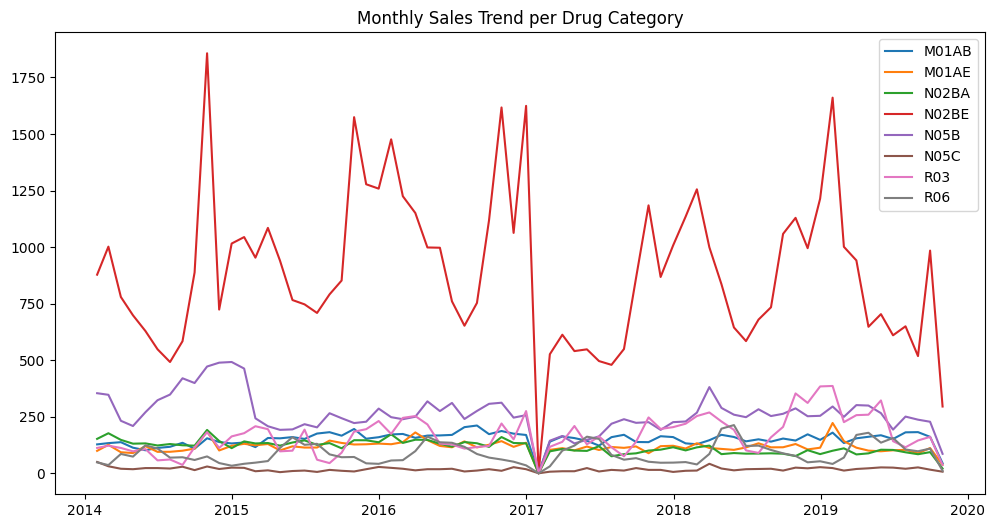

In [19]:
plt.figure(figsize=(12, 6))

for drug in drug_columns:
    plt.plot(monthly_clean['datum'], monthly_clean[drug], label = drug)

plt.title('Monthly Sales Trend per Drug Category')
plt.legend()
plt.show()

In [20]:
total_sales = monthly_clean[drug_columns].sum().sort_values(ascending=False)
percent_sales = (total_sales / total_sales.sum()) * 100

print("--- ABC Analysis Results ---")
print(percent_sales)

--- ABC Analysis Results ---
N02BE    49.356214
N05B     14.494757
R03       9.272171
M01AB     8.294329
M01AE     6.443062
N02BA     6.360477
R06       4.792308
N05C      0.986683
dtype: float64


--- (ABC Analysis) ---
N02BE: percent 49.36%
N05B: percent 14.49%
R03: percent 9.27%
M01AB: percent 8.29%
M01AE: percent 6.44%
N02BA: percent 6.36%
R06: percent 4.79%
N05C: percent 0.99%


C:\Users\Toroko\AppData\Local\Temp\ipykernel_19752\396225912.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=percent_sales.index, y=percent_sales.values, palette='viridis')


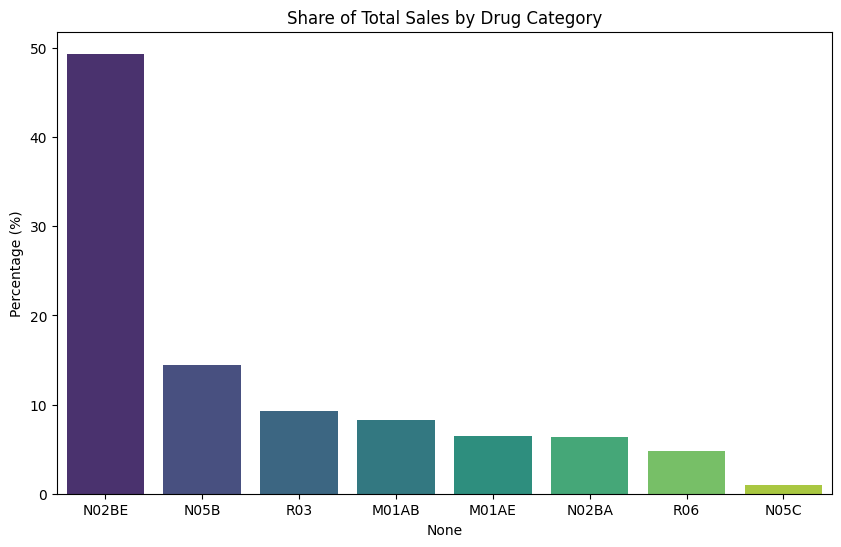

In [22]:
# คำนวณยอดขายรวมของยาแต่ละชนิดจากไฟล์ Monthly
drug_list = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']
total_sales_per_drug = monthly_clean[drug_list].sum().sort_values(ascending=False)

# คำนวณสัดส่วน %
percent_sales = (total_sales_per_drug / total_sales_per_drug.sum()) * 100

print("--- (ABC Analysis) ---")
for drug, percent in percent_sales.items():
    print(f"{drug}: percent {percent:.2f}%")

# พลอตกราฟให้สวยงามเอาไปแปะ Notion
plt.figure(figsize=(10, 6))
sns.barplot(x=percent_sales.index, y=percent_sales.values, palette='viridis')
plt.title('Share of Total Sales by Drug Category')
plt.ylabel('Percentage (%)')
plt.show()

In [24]:
daily_clean.to_csv('data/daily_sales_cleaned.csv', index=False)
print("✅ Cleaned data saved successfully!")
monthly_clean.to_csv('data/monthly_sales_cleaned.csv', index=False)
print("✅ Cleaned data saved successfully!")

✅ Cleaned data saved successfully!
✅ Cleaned data saved successfully!
